# Budgeted MLMC vs MLQMC for the Analytic Function 

## Imports

In [1]:
import mlqmcpy as mp
from mlqmcpy.problems import analytic, elliptic, asian_option, borehole

In [2]:
import numpy as np
import scipy.stats
import qmcpy as qp
import time
import os

In [ ]:
import matplotlib 
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
#pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

: 

## Experiment

In [ ]:
force_experiment = False
#problem_dim_levels = (analytic,2,10)
#problem_dim_levels = (borehole,8,2)
problem_dim_levels = (elliptic,8,4)
#problem_dim_levels = (asian_option,16,8)
problem,dimension,num_levels = problem_dim_levels
dataroot = "budgeted_comparison_data/comp.%s.d%d.levels%d.DNET.FULL/"%(problem.__name__,dimension,num_levels)
if not os.path.exists(dataroot): os.makedirs(dataroot)
if not os.path.isfile(dataroot+"data.npy") or force_experiment:
    # parameters 
    max_budgets = 2**np.arange(7,12)
    initial_cost_prop_max_budget = 1/4
    kwargs_fastgp_fit = {"loss_metric":"MLL","stop_crit_improvement_threshold":1e0,"verbose":0}
    refit_igps = True
    refit_mtgps = True
    n_ref = 2**19
    replications = 8
    trials = 100
    verbose = max(1,trials//10)
    zip_name_IteratorClass_kwargs = [
        ## MLMC
        ("MLMC    IID",mp.GreedyMLMCIterator,{}),
        ## R-MLQMC
        # ##  LATTICE
        # ("R-MLQMC Lattice",mp.GreedyMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"replications":replications}),
        ##  DNET 
        ("R-MLQMC DNet",mp.GreedyMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"replications":replications}),
        ## IGP 
        ##   FAST
        # ##       LATTICE 
        # (r"IGP    Lattice  Fast  SI  $\alpha=2$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"kwargs_fastgp_construct":{"alpha":2},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        # (r"IGP    Lattice  Fast  SI  $\alpha=3$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"kwargs_fastgp_construct":{"alpha":3},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        # (r"IGP    Lattice  Fast  SI  $\alpha=4$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"kwargs_fastgp_construct":{"alpha":4},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        # (r"IGP    Lattice  Fast  SI  $\alpha=5$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"kwargs_fastgp_construct":{"alpha":5},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        ##       DNET
        (r"IGP    DNet     Fast  DSI $\alpha=1$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"kwargs_fastgp_construct":{"alpha":1},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        (r"IGP    DNet     Fast  DSI $\alpha=2$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"kwargs_fastgp_construct":{"alpha":2},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        (r"IGP    DNet     Fast  DSI $\alpha=3$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"kwargs_fastgp_construct":{"alpha":3},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        (r"IGP    DNet     Fast  DSI $\alpha=4$",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"kwargs_fastgp_construct":{"alpha":4},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        # ##   SLOW        
        # ##       Lattice
        # (r"IGP    Lattice  Slow  SE",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":False,"kwargs_fastgp_construct":{},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        # ##       DNET 
        # (r"IGP    DNet     Slow  SE",mp.GreedyGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":False,"kwargs_fastgp_construct":{},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_igps}),
        ## MTGP
        ##   FAST 
        # ##       LATTICE
        # (r"MTGP   Lattice  Fast  SI  $\alpha=2$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":2,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        # (r"MTGP   Lattice  Fast  SI  $\alpha=3$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":3,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        # (r"MTGP   Lattice  Fast  SI  $\alpha=4$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":4,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        # (r"MTGP   Lattice  Fast  SI  $\alpha=5$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":5,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        ##       DNET
        (r"MTGP   DNet     Fast  DSI $\alpha=1$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":1,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        (r"MTGP   DNet     Fast  DSI $\alpha=2$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":2,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        (r"MTGP   DNet     Fast  DSI $\alpha=3$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":3,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        (r"MTGP   DNet     Fast  DSI $\alpha=4$ Greedy",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":True,"budget_scheme":"greedy","kwargs_fastgp_construct":{"alpha":4,"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit,"refit_gps":refit_mtgps}),
        # ##   SLOW
        # ##       LATTICE
        # (r"MTGP   Lattice  Slow  SE",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.Lattice,"fast":False,"budget_scheme":"greedy","kwargs_fastgp_construct":{"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit},"refit_gps":refit_mtgps),
        # ##       DNET
        # (r"MTGP   DNet     Slow  SE",mp.MultiTaskGaussianProcessMLQMCIterator,{"discrete_distribution_type":qp.DigitalNetB2,"fast":False,"budget_scheme":"greedy","kwargs_fastgp_construct":{"rank_factor_task_kernel":num_levels},"kwargs_fastgp_fit":kwargs_fastgp_fit},"refit_gps":refit_mtgps),
    ]
    # experiment
    t0 = time.perf_counter()
    names = [name for (name,IteratorClass,kwargs) in zip_name_IteratorClass_kwargs]
    if hasattr(problem,"exact") and hasattr(problem.exact,"Q") and hasattr(problem.exact.Q,"mean"):
        true_solution = problem.exact.Q.mean(level=num_levels-1)
    else:
        x = qp.DigitalNetB2(dimension)(n_ref)
        y = problem(num_levels-1,x)
        true_solution = y.mean()
    cost_per_level = 2.**(np.arange(num_levels)-num_levels+1) # Rescale so that finest level has unit cost
    print("max_budgets: %s"%max_budgets)
    print("cost_per_level: %s"%str(cost_per_level))
    print("true_solution = %.5e"%true_solution)
    print()
    costs = np.empty((len(zip_name_IteratorClass_kwargs),len(max_budgets),trials))
    means = np.empty((len(zip_name_IteratorClass_kwargs),len(max_budgets),trials))
    std_errors = np.empty((len(zip_name_IteratorClass_kwargs),len(max_budgets),trials))
    true_errors = np.empty((len(zip_name_IteratorClass_kwargs),len(max_budgets),trials))
    samples_per_level = np.empty((len(zip_name_IteratorClass_kwargs),len(max_budgets),trials,num_levels),dtype=int)
    for j in range(len(max_budgets)):
        max_budget = max_budgets[j]
        initial_budget = int(initial_cost_prop_max_budget*max_budget)
        print("budget = %d, initial budget = %d"%(max_budget,initial_budget))
        initial_sample_size_og = initial_budget/num_levels/cost_per_level
        for i,(name,IteratorClass,kwargs) in enumerate(zip_name_IteratorClass_kwargs):
            if IteratorClass==mp.GreedyMLQMCIterator:
                initial_sample_size = initial_sample_size_og/kwargs["replications"]
                initial_sample_size = 2**np.ceil(np.log2(initial_sample_size)).astype(int)
                initial_cost = kwargs["replications"]*(initial_sample_size*cost_per_level).sum()
            else:
                initial_sample_size = 2**np.ceil(np.log2(initial_sample_size_og)).astype(int)
                initial_cost = (initial_sample_size*cost_per_level).sum()
            print("\t%s, \t initial_sample_size = %s, \tinitial cost = %.1f"%(name,str(initial_sample_size.tolist()),initial_cost))
            for t in range(trials):
                iterator = IteratorClass(
                    dimension,
                    initial_sample_size = initial_sample_size,
                    cost_per_level = cost_per_level,
                    max_budget = max_budget,
                    **kwargs)
                problem_l_or_ml = problem if isinstance(iterator,mp.MultiTaskGaussianProcessMLQMCIterator) else problem.ml
                problem_tf = (lambda level,x: problem_l_or_ml(level,1-2*np.abs(x-1/2))) if iterator.discrete_distribution_type==qp.Lattice else problem_l_or_ml
                for iter, new_samples in enumerate(iterator):
                    new_results = {level: problem_tf(level,samples) for level,samples in new_samples.items()}
                    iterator.update(new_results)
                costs[i,j,t] = iterator.cost
                means[i,j,t] = iterator.mean
                std_errors[i,j,t] = iterator.standard_error
                true_errors[i,j,t] = np.abs(true_solution-means[i,j,t])
                samples_per_level[i,j,t] = iterator.total_samples_per_level.copy()
                if verbose and t%verbose==0:
                    print("\t\ttrial: %-6d iteration: %-6d cost: %-10d mean: %-15.3e std error: %-15.3e true error: %-15.3e time %-15d sample sizes %s"%\
                    (t,iter,costs[i,j,t],means[i,j,t],std_errors[i,j,t],true_errors[i,j,t],int(np.ceil(time.perf_counter()-t0)),str(samples_per_level[i,j,t].tolist())))
        print()
    data = {
        "dimension": dimension,
        "num_levels": num_levels,
        "max_budgets": max_budgets,
        "initial_cost_prop_max_budget": initial_cost_prop_max_budget,
        "names": names,
        "costs": costs,
        "means": means,
        "std_errors": std_errors,
        "true_errors": true_errors,
        "kwargs_fastgp_fit": kwargs_fastgp_fit,
        "refit_gps":refit_igps,
        "n_ref":n_ref,
    }
    np.save(dataroot+"data.npy",data)
else:
    data = np.load(dataroot+"data.npy",allow_pickle=True)[()]
    dimension = data["dimension"]
    num_levels = data["num_levels"]
    initial_cost_prop_max_budget = data["initial_cost_prop_max_budget"]
    max_budgets = data["max_budgets"]
    names = data["names"]
    costs = data["costs"]
    means = data["means"]
    std_errors = data["std_errors"]
    true_errors = data["true_errors"]
    kwargs_fastgp_fit = data["kwargs_fastgp_fit"]
    refit_igps = data["refit_gps"]
    n_ref = data["n_ref"]
    trials = costs.shape[-1]

max_budgets: [ 128  256  512 1024 2048]
cost_per_level: [0.125 0.25  0.5   1.   ]
true_solution = 1.49941e-01

budget = 128, initial budget = 32
	MLMC    IID, 	 initial_sample_size = [64, 32, 16, 8], 	initial cost = 32.0
		trial: 0      iteration: 7      cost: 128        mean: 1.410e-01       std error: 8.364e-03       true error: 8.930e-03       time 30              sample sizes [512, 128, 32, 16]
		trial: 10     iteration: 7      cost: 128        mean: 1.668e-01       std error: 8.512e-03       true error: 1.687e-02       time 31              sample sizes [512, 128, 32, 16]
		trial: 20     iteration: 7      cost: 128        mean: 1.485e-01       std error: 9.270e-03       true error: 1.424e-03       time 31              sample sizes [512, 128, 32, 16]
		trial: 30     iteration: 7      cost: 128        mean: 1.522e-01       std error: 7.126e-03       true error: 2.248e-03       time 32              sample sizes [512, 128, 32, 16]
		trial: 40     iteration: 7      cost: 128        mean

## Analysis

above 0 means it is over budget, below 0 means it is within the budget


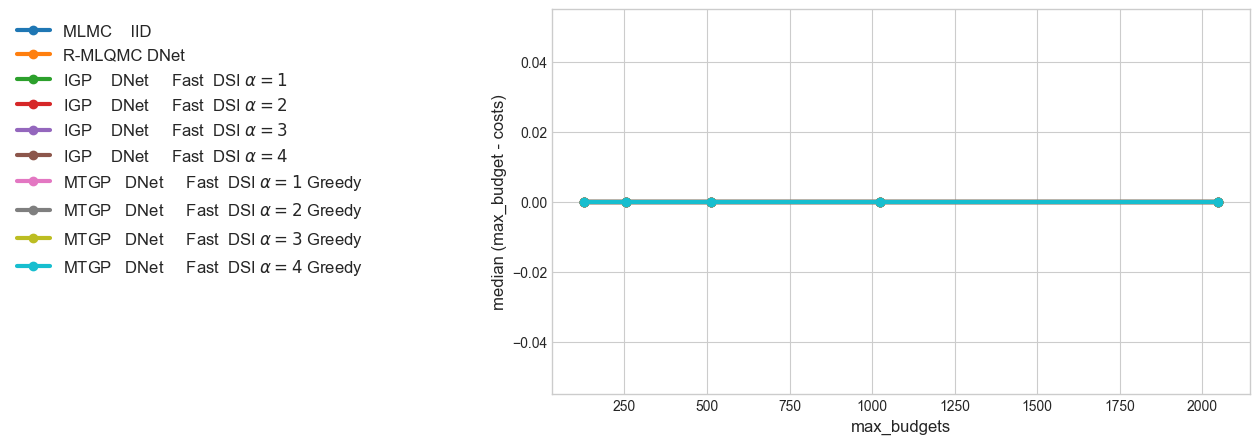

In [ ]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(9,5))
for i,name in enumerate(names):
    vals = costs[i]-max_budgets[:,None]
    q_low = np.nanquantile(vals,.1,axis=1)
    q_med = np.nanquantile(vals,.5,axis=1)
    q_high = np.nanquantile(vals,.9,axis=1)
    ax.plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
    ax.fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax.legend(frameon=False,fontsize="large",bbox_to_anchor=(-.25,1))
ax.set_xlabel("max_budgets",fontsize="large")
ax.set_ylabel("median (max_budget - costs)",fontsize="large");
print("above 0 means it is over budget, below 0 means it is within the budget")

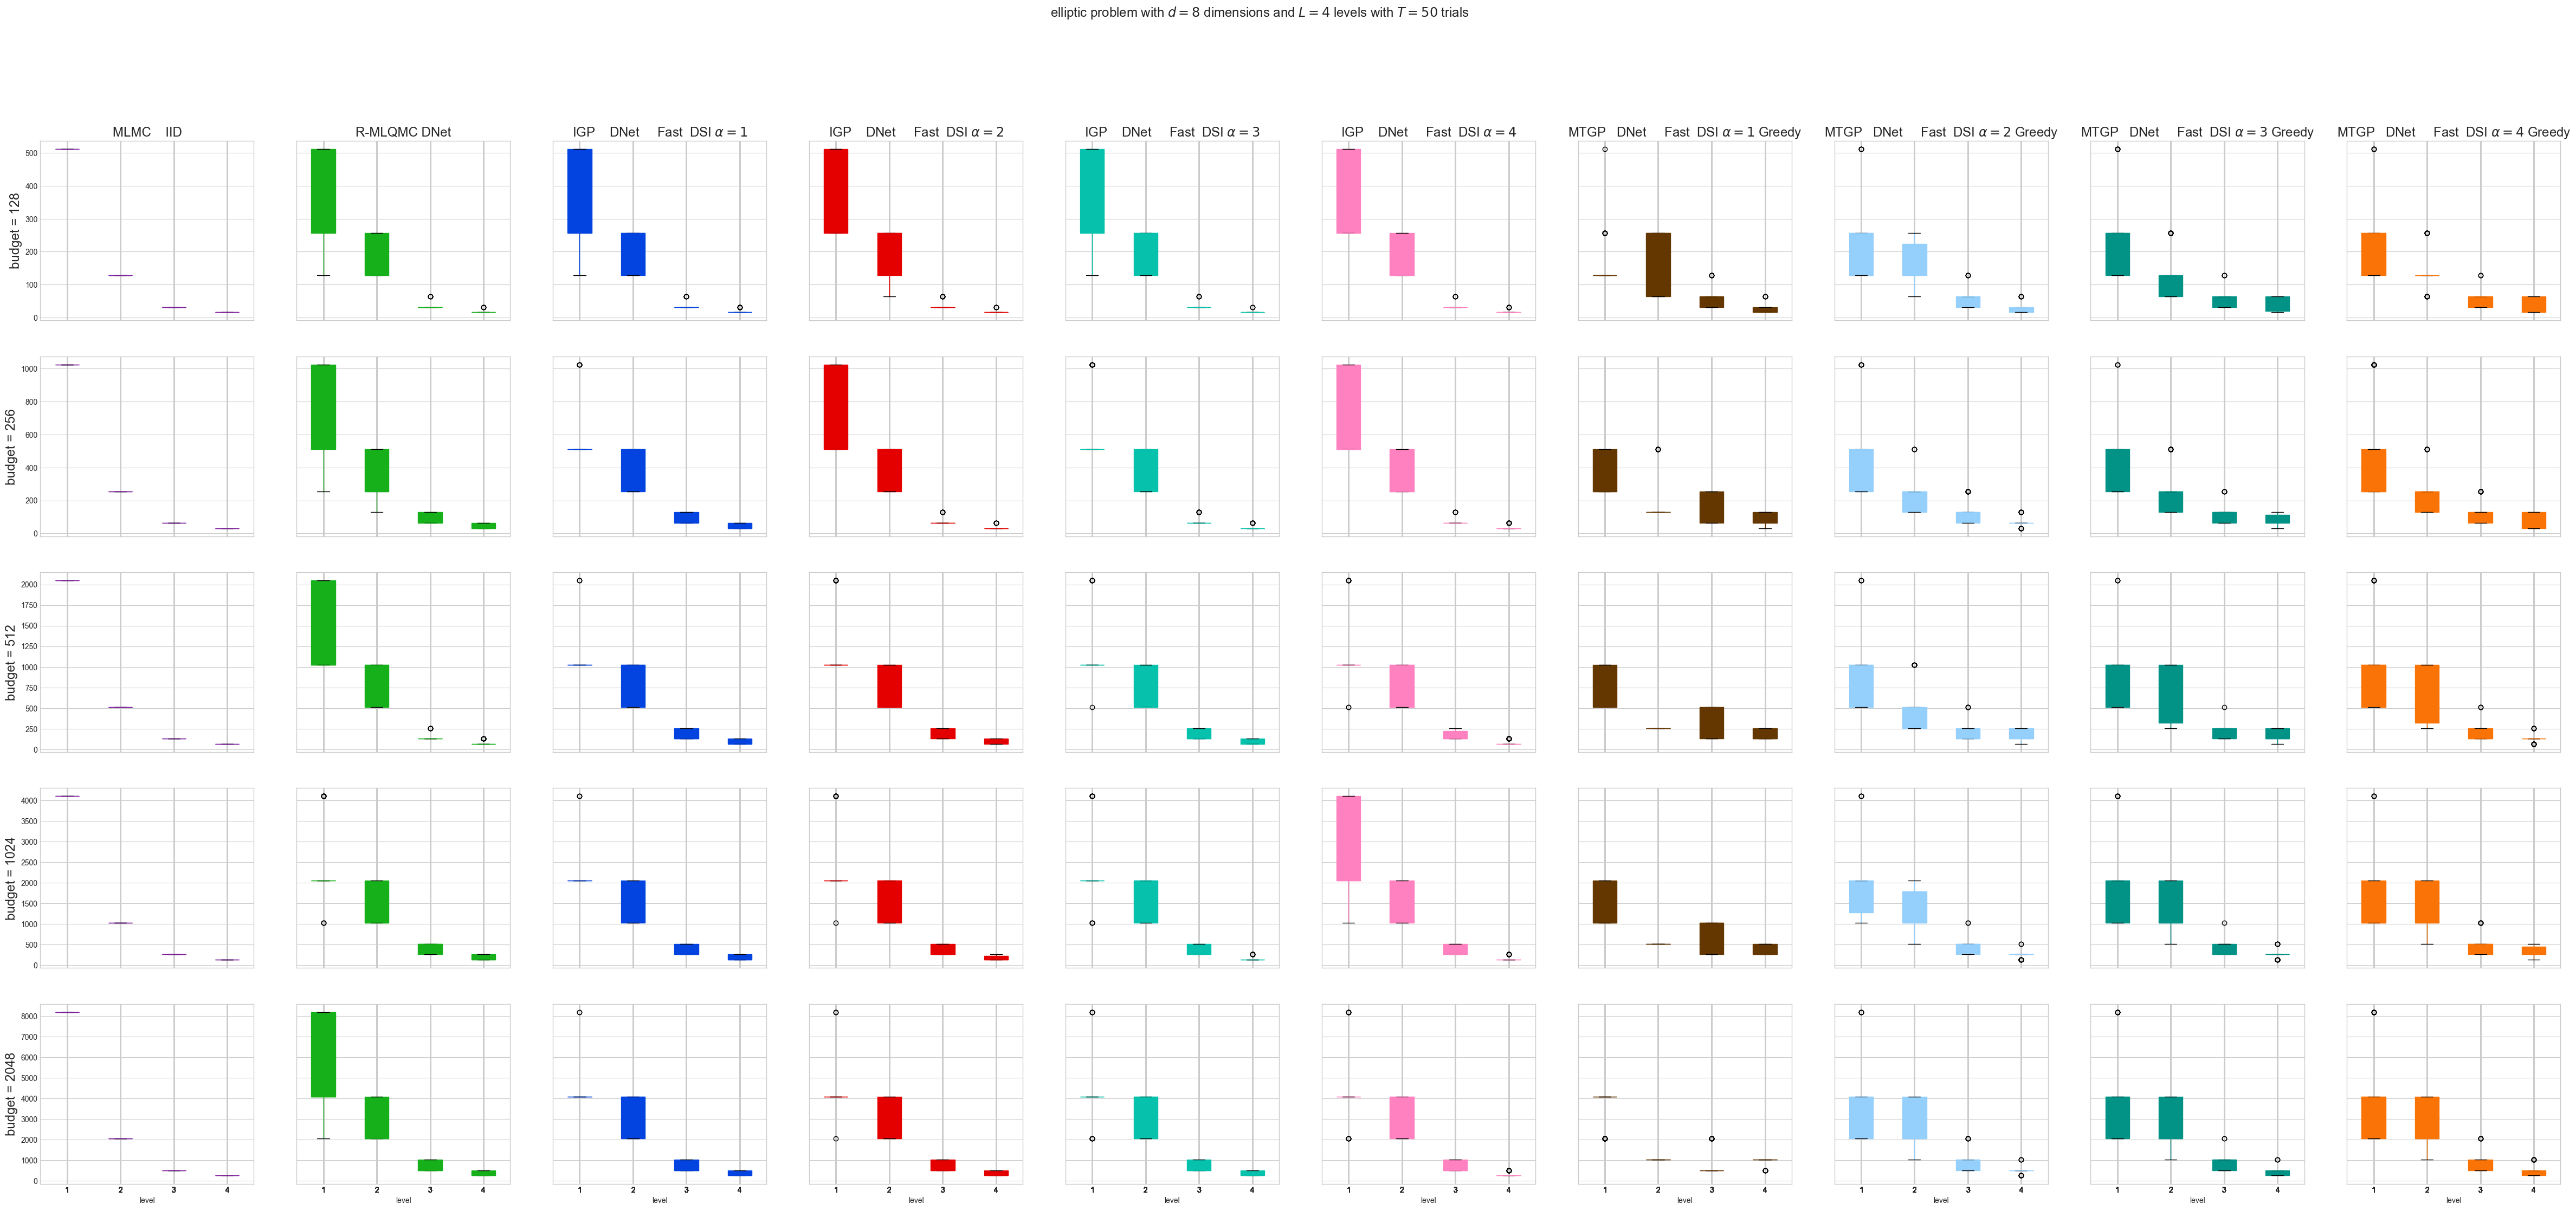

In [ ]:
nrows = len(max_budgets)
ncols = len(names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(6*ncols,5*nrows),sharey="row",sharex=True)
for i in range(nrows):
    for j in range(ncols):
        bplot = ax[i,j].boxplot(samples_per_level[j,i,:,:],orientation="vertical",label=names[j],patch_artist=True,notch=False);
        for _attr in ['boxes','means']:
            for patch in bplot[_attr]: patch.set_facecolor(COLORS[j])
        for _attr in ['medians','fliers','whiskers','medians','means','boxes']:
            for patch in bplot[_attr]: patch.set_color(COLORS[j])
    ax[i,0].set_ylabel("budget = %d"%max_budgets[i],fontsize="xx-large")
for j in range(ncols):
    ax[0,j].set_title(names[j],fontsize="xx-large")
    ax[-1,j].set_xlabel("level")
fig.suptitle(r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials),fontsize="xx-large")
#fig.tight_layout()
fig.savefig(dataroot+"sample_allocation.pdf",transparent=True,bbox_inches="tight")

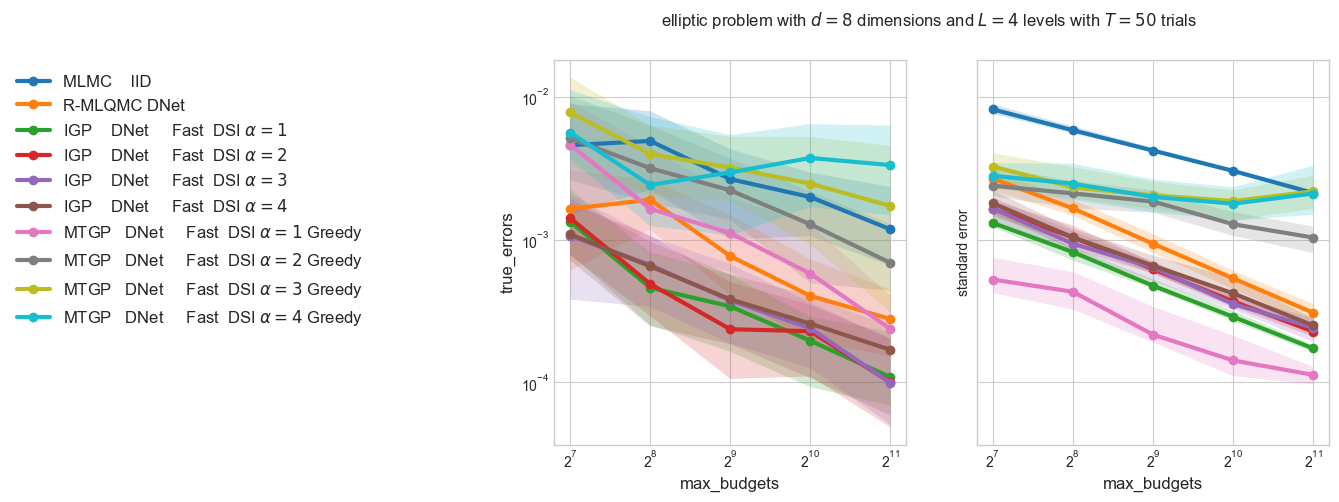

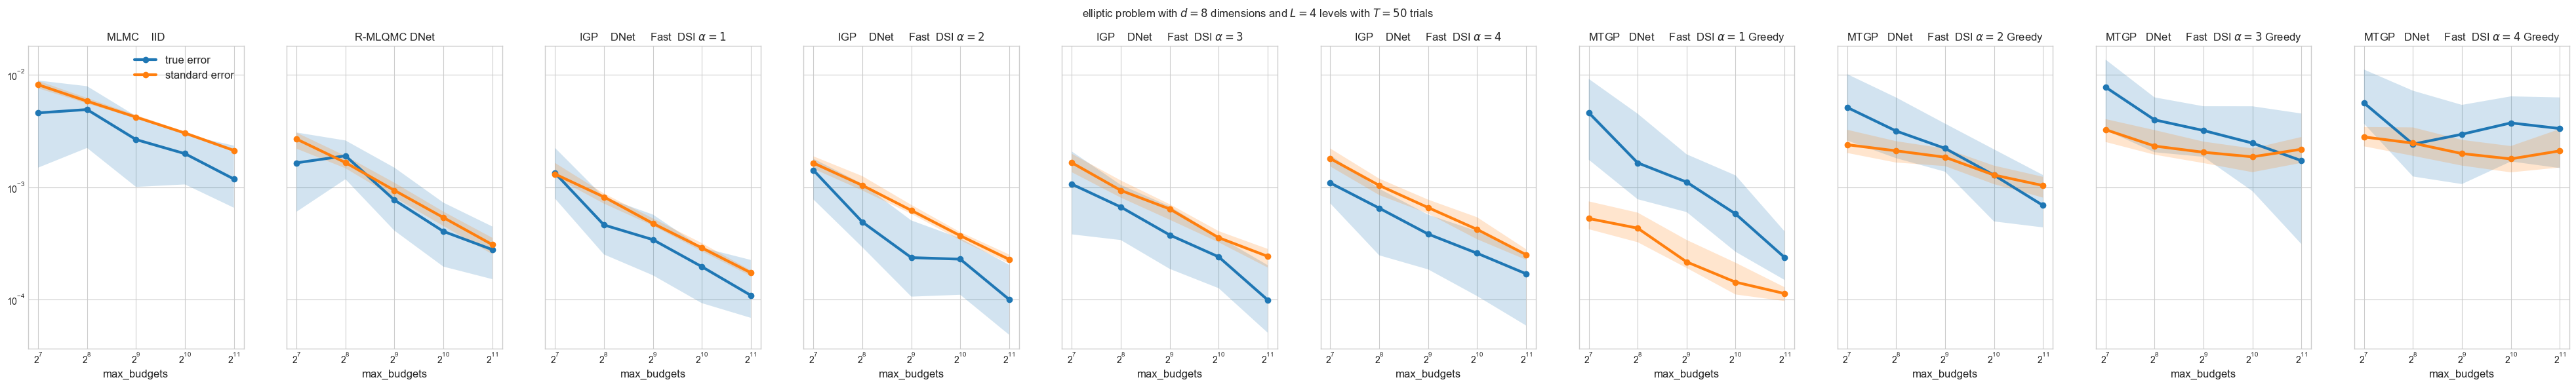

In [ ]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(5*2,5),sharey=True,sharex=True)
for i,name in enumerate(names):
    for j,vals in enumerate([true_errors[i],std_errors[i]]):
        q_low = np.nanquantile(vals,.25,axis=1)
        q_med = np.nanquantile(vals,.5,axis=1)
        q_high = np.nanquantile(vals,.75,axis=1)
        ax[j].plot(max_budgets,q_med,'-o',label=name,linewidth=LW,alpha=1)
        #ax[j].scatter(costs[i],vals,color=COLORS[i])
        ax[j].fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax[0].legend(frameon=False,fontsize="large",bbox_to_anchor=(-.5,1))
ax[0].set_yscale("log",base=10)
ax[0].set_xscale("log",base=2)
ax[0].set_ylabel("true_errors",fontsize="large")
ax[1].set_ylabel("standard error")
for j in range(2):
    ax[j].set_xlabel("max_budgets",fontsize="large")
fig.suptitle(r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials),fontsize="large");
fig.savefig(dataroot+"convergence_by_error.pdf",transparent=True,bbox_inches="tight")
fig,ax = pyplot.subplots(nrows=1,ncols=len(names),figsize=(5*len(names),5+1),sharey=True,sharex=True)
for i,name in enumerate(names):
    for j,(error_metric,vals) in enumerate(zip(["true error","standard error"],[true_errors[i],std_errors[i]])):
        q_low = np.nanquantile(vals,.25,axis=1)
        q_med = np.nanquantile(vals,.5,axis=1)
        q_high = np.nanquantile(vals,.75,axis=1)
        ax[i].plot(max_budgets,q_med,'-o',label=error_metric,linewidth=LW,alpha=1)
        #ax[j].scatter(costs[i],vals,color=COLORS[i])
        ax[i].fill_between(max_budgets,q_low,q_high,alpha=alpha)
        ax[i].set_title(name,fontsize="large")
ax[0].legend(frameon=False,fontsize="large")
ax[0].set_yscale("log",base=10)
ax[0].set_xscale("log",base=2)
for j in range(len(names)):
    ax[j].set_xlabel("max_budgets",fontsize="large")
fig.suptitle(r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials),fontsize="large");
fig.savefig(dataroot+"convergence_by_method.pdf",transparent=True,bbox_inches="tight")

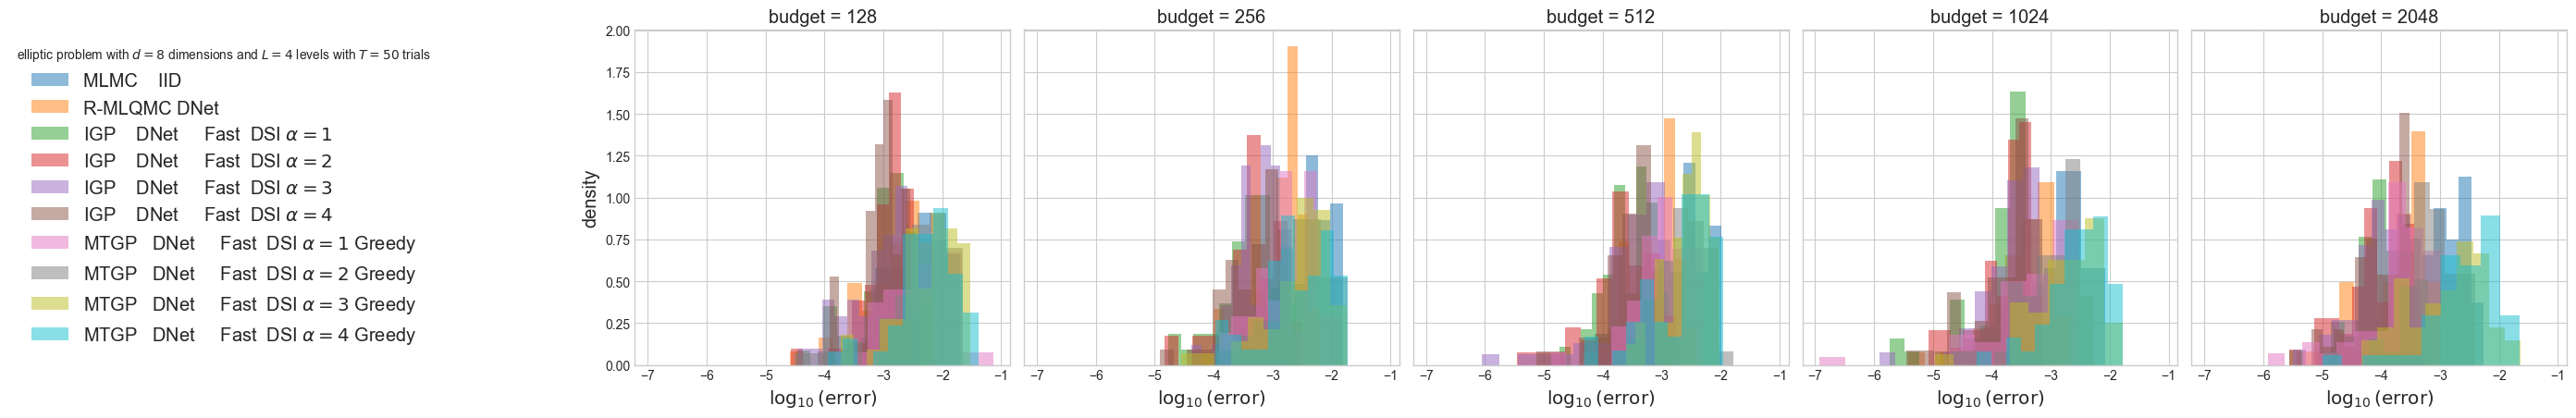

In [ ]:
fig,ax = pyplot.subplots(nrows=1,ncols=len(max_budgets),figsize=(WIDTH*2,WIDTH/(len(max_budgets)+1)*2),sharex=True,sharey=True)
for j in range(len(max_budgets)):
    for i,name in enumerate(names):
        ax[j].hist(np.log10(true_errors[i,j]),label=name,density=True,bins=10,alpha=.5) 
    ax[j].set_xlabel(r"$\log_{10}(\mathrm{error})$",fontsize="x-large")
    ax[j].set_title("budget = %d"%max_budgets[j],fontsize="x-large")
ax[0].legend(frameon=False,bbox_to_anchor=(-.5,1),title=r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials),fontsize="x-large")#,ncol=len(names))
ax[0].set_ylabel("density",fontsize="x-large")
fig.tight_layout()
#ax[0].set_xscale("log",base=10)
fig.savefig(dataroot+"densities.pdf",transparent=True,bbox_inches="tight")

/var/folders/xk/w1s5c54x0zv90dgqk3vpmbsw004hmz/T/ipykernel_54200/1346571151.py:14


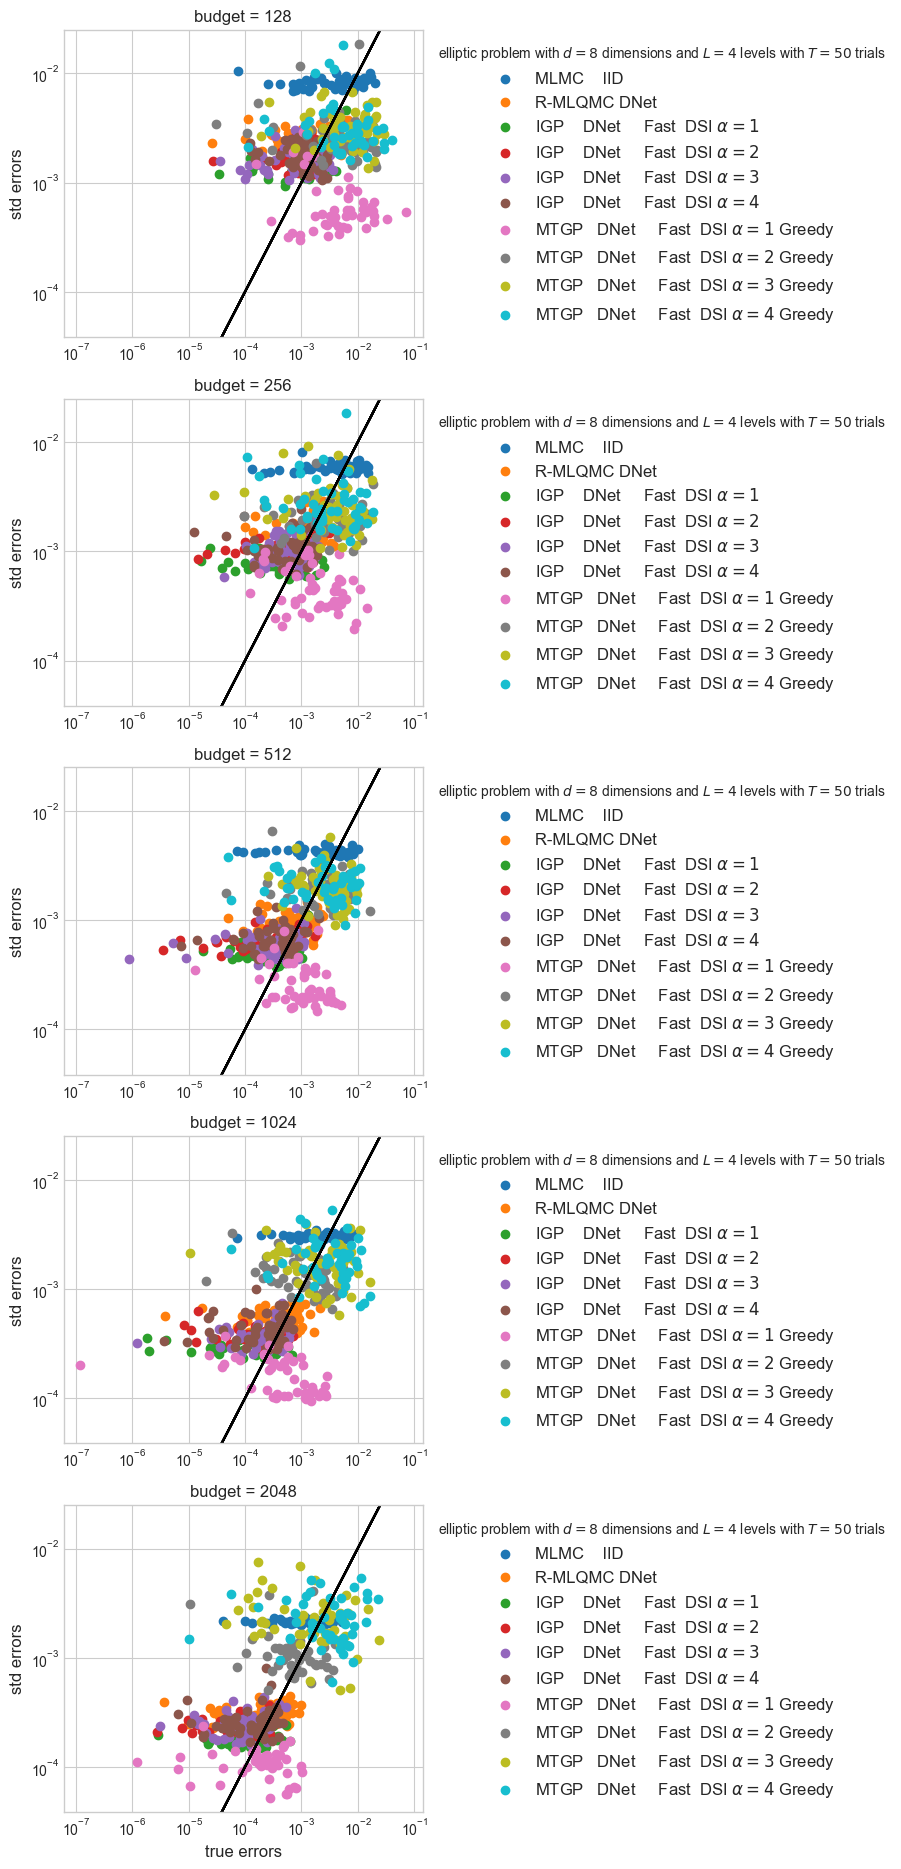

In [ ]:
fig,ax = pyplot.subplots(nrows=len(max_budgets),ncols=1,figsize=(WIDTH/3,WIDTH*len(max_budgets)/3),sharex=True,sharey=True)
for i,name in enumerate(names):
    for j in range(len(max_budgets)):
        ax[j].scatter(true_errors[i,j],std_errors[i,j],label=name)
        ax[j].axline(xy1=(0,0),slope=1,color="k")
ax[0].set_xscale("log",base=10)
ax[0].set_yscale("log",base=10)
for j in range(len(max_budgets)):
    ax[j].legend(frameon=False,fontsize="large",bbox_to_anchor=(1,1),title=r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials))#,ncols=len(max_budgets),)
    ax[j].set_title("budget = %d"%max_budgets[j])
    ax[j].xaxis.set_tick_params(labelbottom=True)
    ax[j].set_ylabel("std errors",fontsize="large")
ax[-1].set_xlabel("true errors",fontsize="large")
fig.tight_layout()
fig.savefig(dataroot+"error_scatters.pdf",transparent=True,bbox_inches="tight")